In [7]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare

In [8]:
def outcome(pred_base, pred_weighted, label, mode="2class"):
    """
    Compare baseline and weighted model predictions using a given evaluation mode.
    mode: one of {"regression", "7class", "5class", "2class", "2class_non0"}
    """

    if mode == "7class":
        base_correct = int(np.clip(pred_base, -3, 3)) == int(np.clip(label, -3, 3))
        weighted_correct = int(np.clip(pred_weighted, -3, 3)) == int(np.clip(label, -3, 3))

    elif mode == "5class":
        base_correct = int(np.clip(pred_base, -2, 2)) == int(np.clip(label, -2, 2))
        weighted_correct = int(np.clip(pred_weighted, -2, 2)) == int(np.clip(label, -2, 2))

    elif mode == "2class":
        base_correct = (pred_base >= 0) == (label >= 0)
        weighted_correct = (pred_weighted >= 0) == (label >= 0)

    elif mode == "2class_non0":
        if label == 0:
            return "ignore"
        base_correct = (pred_base > 0) == (label > 0)
        weighted_correct = (pred_weighted > 0) == (label > 0)

    else:
        raise ValueError("Unknown mode")

    if not base_correct and weighted_correct:
        return "corrected"
    elif base_correct and not weighted_correct:
        return "regressed"
    elif base_correct and weighted_correct:
        return "both_correct"
    else:
        return "both_wrong"


In [9]:
import ast

def to_float(x):
    if isinstance(x, float) or isinstance(x, int):
        return float(x)
    elif isinstance(x, list):
        return float(x[0])
    elif isinstance(x, str) and x.startswith("["):
        try:
            return float(ast.literal_eval(x)[0])
        except:
            return float('nan')
    else:
        return float(x)

In [10]:
def run_outcome_analysis(root_path, paths, dataset, model_base='baseline', model_weighted='KL'):
    # Load CSVs
    runs = {}
    for run_name, path in paths.items():
        df_train = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_train_results.csv')
        df_dev   = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_dev_results.csv')
        df_test  = pd.read_csv(f'{root_path}/{path}/{dataset}_text_audio_video_1_test_results.csv')

        #df_train["split"] = "train"
        #df_dev["split"]   = "dev"
        df_test["split"]  = "test"

        runs[run_name] = pd.concat([df_test], ignore_index=True)

    # Merge base and weighted runs
    merged = runs[model_base].merge(runs[model_weighted], on='ids', suffixes=(f'_{model_base}', f'_{model_weighted}'))

    # Keep a consistent GT and split column
    merged['Ground_Truth'] = merged[f'Ground_Truth_{model_base}']
    assert (merged[f'split_{model_base}'] == merged[f'split_{model_weighted}']).all()
    merged['split'] = merged[f'split_{model_base}']

    # Convert to float
    for col in [f'Predicted_{model_base}', f'Predicted_{model_weighted}', 'Ground_Truth']:
        merged[col] = merged[col].apply(to_float)

    # Classification-style outcome labeling
    modes = ["7class", "5class", "2class", "2class_non0"]
    for mode in modes:
        merged[f'outcome_{mode}'] = merged.apply(
            lambda r: outcome(r[f'Predicted_{model_base}'], r[f'Predicted_{model_weighted}'], r['Ground_Truth'], mode),
            axis=1
        )

    # Regression error analysis
    regression_df = merged[["ids", "split", f'Predicted_{model_base}', f'Predicted_{model_weighted}', "Ground_Truth"]].copy()
    regression_df["err_baseline"] = abs(regression_df[f'Predicted_{model_base}'] - regression_df["Ground_Truth"])
    regression_df["err_weighted"] = abs(regression_df[f'Predicted_{model_weighted}'] - regression_df["Ground_Truth"])
    regression_df["delta_err"] = regression_df["err_weighted"] - regression_df["err_baseline"]

    # Print summary for classification modes
    summary = {}
    for mode in modes:
        counts = merged[f'outcome_{mode}'].value_counts()
        summary[mode] = {
            'corrected': counts.get('corrected', 0),
            'regressed': counts.get('regressed', 0),
            'both_correct': counts.get('both_correct', 0),
            'both_wrong': counts.get('both_wrong', 0),
            'net_gain': counts.get('corrected', 0) - counts.get('regressed', 0)
        }

    print(pd.DataFrame(summary).T)
    print("\nRegression ΔError (weighted - baseline):")
    print(regression_df["delta_err"].describe())

    return merged, regression_df


# Local Residual KL

In [11]:
root_path = "/data/wang/junh/results/MMIM/"
paths = {
    "baseline":  "final/noWeights",
    "KL":        "final/global_kl",
}

In [12]:
dataset = "mosi"
merged_mosi_kl, regression_mosi_kl = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL")

             corrected  regressed  both_correct  both_wrong  net_gain
7class              83         83           264         256         0
5class              83         85           268         250        -2
2class              39         30           525          92         9
2class_non0         30         29           522          75         1

Regression ΔError (weighted - baseline):
count    686.000000
mean       0.002227
std        0.500450
min       -2.383188
25%       -0.228481
50%        0.016012
75%        0.255531
max        1.996379
Name: delta_err, dtype: float64


In [27]:
merged_mosi_kl.head()

,ids,Predicted_baseline,Ground_Truth_baseline,std_baseline,split_baseline,Predicted_KL,Ground_Truth_KL,std_KL,split_KL,Ground_Truth,split,outcome_7class,outcome_5class,outcome_2class,outcome_2class_non0
0,c7UH_rxdZv4_10,-1.069632,[0.8],[1.8696318],test,-0.922866,[0.8],[1.722866],test,0.8,test,corrected,corrected,both_wrong,both_wrong
1,c7UH_rxdZv4_9,-0.139029,[-0.4],[-0.26097116],test,-0.077713,[-0.4],[-0.32228717],test,-0.4,test,both_correct,both_correct,both_correct,both_correct
2,c7UH_rxdZv4_6,-1.101622,[-2.6],[-1.4983784],test,-1.839198,[-2.6],[-0.76080227],test,-2.6,test,both_wrong,both_wrong,both_correct,both_correct
3,c7UH_rxdZv4_27,-0.665876,[-1.8],[-1.134124],test,-0.496018,[-1.8],[-1.3039818],test,-1.8,test,both_wrong,both_wrong,both_correct,both_correct
4,c7UH_rxdZv4_20,-0.921555,[-1.8],[-0.8784452],test,-0.656712,[-1.8],[-1.1432884],test,-1.8,test,both_wrong,both_wrong,both_correct,both_correct


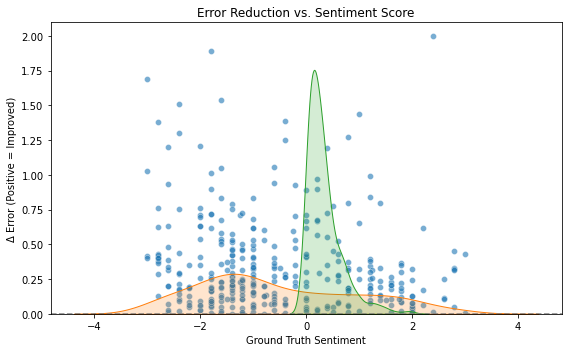

In [33]:
corrected_reg = regression_mosi_kl[regression_mosi_kl["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)


plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

In [14]:
dataset = "mosei"
merged_mosei_kl, regression_mosei_kl = run_outcome_analysis(root_path, paths, dataset, model_base="baseline", model_weighted="KL")

             corrected  regressed  both_correct  both_wrong  net_gain
7class             478        460          2463        1258        18
5class             500        460          2463        1236        40
2class             610        266          3257         526       344
2class_non0        311        248          2742         333        63

Regression ΔError (weighted - baseline):
count    4659.000000
mean       -0.011317
std         0.401286
min        -2.571823
25%        -0.221796
50%        -0.017670
75%         0.191322
max         2.851974
Name: delta_err, dtype: float64


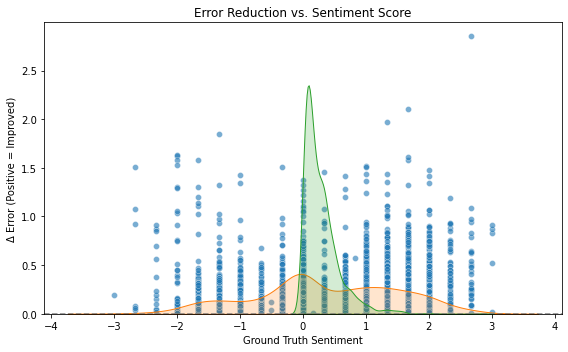

In [34]:
corrected_reg = regression_mosei_kl[regression_mosei_kl["delta_err"] > 0].copy()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Ground_Truth", y="delta_err", data=corrected_reg, alpha=0.6)
sns.kdeplot(x="Ground_Truth", data=corrected_reg, fill=True, alpha=0.2)
sns.kdeplot(x="delta_err", data=corrected_reg, fill=True, alpha=0.2)


plt.axhline(0, color='gray', linestyle='--')
plt.title("Error Reduction vs. Sentiment Score")
plt.xlabel("Ground Truth Sentiment")
plt.ylabel("Δ Error (Positive = Improved)")
plt.tight_layout()
plt.show()

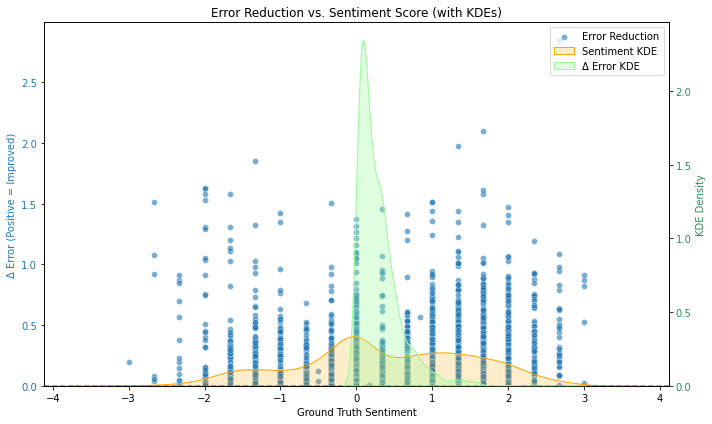

In [26]:
corrected_reg = regression_mosei_kl[regression_mosei_kl["delta_err"] > 0].copy()

plt.figure(figsize=(10, 6))

# Primary axis
ax1 = plt.gca()
scatter = sns.scatterplot(ax=ax1, x="Ground_Truth", y="delta_err", data=corrected_reg,
                          alpha=0.6, label="Error Reduction")
kde_sentiment = sns.kdeplot(ax=ax1, x="Ground_Truth", data=corrected_reg,
                            fill=True, alpha=0.2, label="Sentiment KDE", color="orange")
ax1.axhline(0, color='gray', linestyle='--')
ax1.set_xlabel("Ground Truth Sentiment")
ax1.set_ylabel("Δ Error (Positive = Improved)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Secondary axis for delta_err KDE
ax2 = ax1.twinx()
kde_delta = sns.kdeplot(ax=ax2, x="delta_err", data=corrected_reg,
                        fill=True, alpha=0.3, label="Δ Error KDE", color="palegreen")
ax2.set_ylabel("KDE Density", color="seagreen")
ax2.tick_params(axis='y', labelcolor="seagreen")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title("Error Reduction vs. Sentiment Score (with KDEs)")
plt.tight_layout()
plt.show()